In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# Unzip telecom.zip
with zipfile.ZipFile('telecom.zip', 'r') as zip_ref:
    zip_ref.extractall('telecom_data')

# Unzip retail.zip
with zipfile.ZipFile('retail.zip', 'r') as zip_ref:
    zip_ref.extractall('retail_data')

print('Files unzipped and libraries imported successfully!')

Files unzipped and libraries imported successfully!


## 1. Let's Look at Our Telecom Friends! 📞

First, we need to bring our telecom data into our notebook so we can play with it. Think of it like calling all our friends to come over for a party!

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the telecom datasets
df_telecom_20 = pd.read_csv('telecom_data/churn-bigml-20.csv')
df_telecom_80 = pd.read_csv('telecom_data/churn-bigml-80.csv')

# Put them together into one big list of friends!
df_telecom = pd.concat([df_telecom_20, df_telecom_80], ignore_index=True)

# Let's see the first few friends in our list, just like looking at their names on the party invitation!
display(df_telecom.head())

# And how many friends we have in total and what kind of information we have about them.
print("\nInformation about our telecom friends:")
df_telecom.info()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False



Information about our telecom friends:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  

### A. `PairPlot` for Telecom Data: Seeing Everyone at Once! 👯‍♀️

Imagine you have many friends, and you want to see how tall they are compared to how much they like candy, or how much they like to run compared to how much they like to draw. A `PairPlot` is like drawing a little picture for every pair of things you want to compare, for all your friends!

We'll look at things like how long they've been with the phone company (`account length`), how many messages they send (`number vmail messages`), and how much they talk during the day, evening, and night (`total day minutes`, `total eve minutes`, `total night minutes`).

And we'll color them based on if they stayed with the company (`Churn` is 'False') or left (`Churn` is 'True'), so we can see if friends who left are different from friends who stayed!

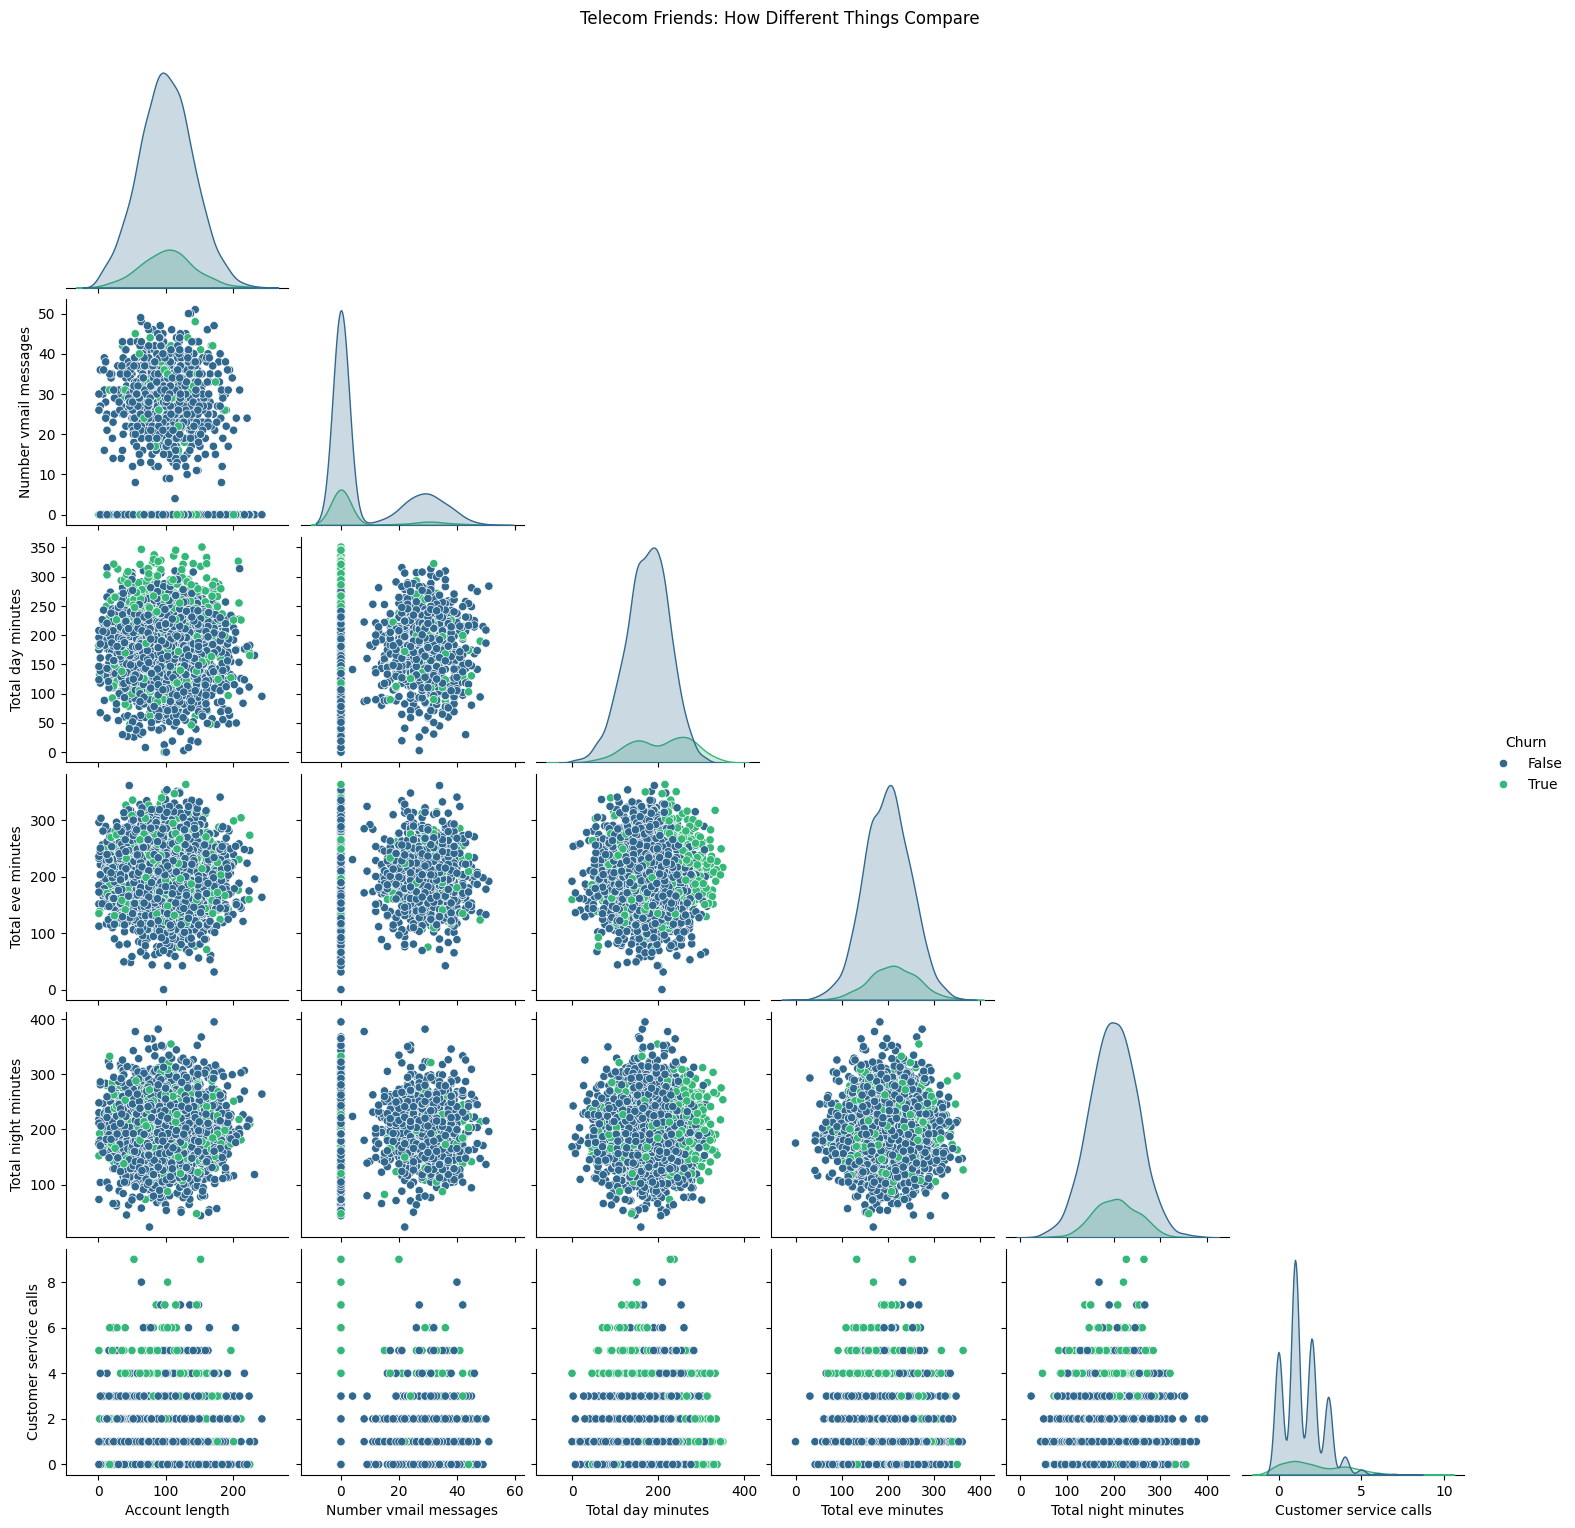

In [12]:
# Let's pick some numbers we want to compare for our telecom friends
vars_to_plot_telecom = [
    "Account length",
    "Number vmail messages",
    "Total day minutes",
    "Total eve minutes",
    "Total night minutes",
    "Customer service calls"
]

# Make the PairPlot!
# `data=df_telecom` means we are using our telecom friends' information.
# `vars=vars_to_plot_telecom` means we picked these specific things to compare.
# `hue="Churn"` means we will color the dots based on whether they stayed or left (churn).
# `palette="viridis"` is just picking nice colors.
# `diag_kind="kde"` means on the diagonal, we draw a smooth hill shape to show where most friends are.
# `corner=True` means we only draw half the pictures, because the other half would be the same but flipped.
# `height=2.5` makes each little picture a good size.
sns.pairplot(
    data=df_telecom,
    vars=vars_to_plot_telecom,
    hue="Churn",
    palette="viridis",
    diag_kind="kde",
    corner=True,
    height=2.5
)

# Give our big picture a name!
plt.suptitle("Telecom Friends: How Different Things Compare", y=1.02)
plt.show()

### B. `FacetGrid` for Telecom Data: Organized Pictures! 🖼️

Now, imagine you want to look at how much friends talk during the day (`total day charge`) and how much they talk in the evening (`total eve charge`), but you want to organize these pictures in a special way.

`FacetGrid` is like having a big board with many smaller windows. Each window shows a picture, and we can decide what kind of picture goes in each window based on different groups of friends.

We'll put friends who have an 'international plan' (talks to friends far away) in different rows, and friends who have a 'voice mail plan' (leaves messages) in different columns. And still color them by whether they stayed or left (`Churn`). This helps us see if these plans make friends behave differently!

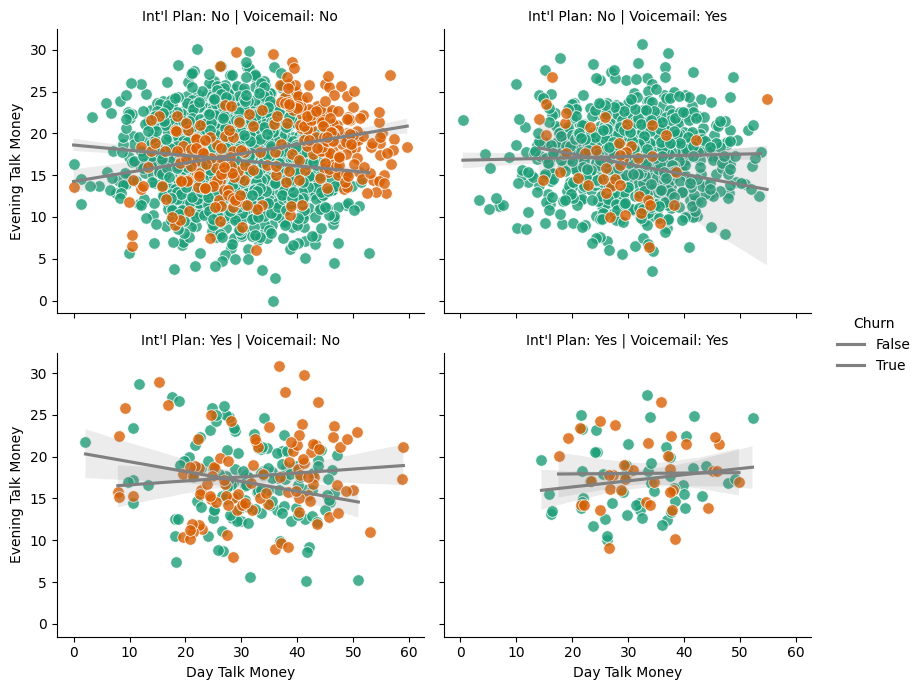

In [13]:
# 1. Get ready to draw our organized pictures!
# `data=df_telecom` - using our telecom friends' info.
# `col="Voice mail plan"` - friends with voice mail in one column, without in another.
# `row="International plan"` - friends with international plan in one row, without in another.
# `hue="Churn"` - color the dots if they stayed or left.
# `palette="Dark2"` - more nice colors.
# `height=3.5`, `aspect=1.2` - make the windows a good size.
g_telecom = sns.FacetGrid(
    data=df_telecom,
    col="Voice mail plan",
    row="International plan",
    hue="Churn",
    palette="Dark2",
    height=3.5,
    aspect=1.2
)

# 2. Draw dots in each window! Each dot is one friend.
# `sns.scatterplot` makes little dots.
# `x="Total day charge"` - how much they spent talking during the day (left-to-right).
# `y="Total eve charge"` - how much they spent talking in the evening (bottom-to-top).
# `s=70`, `alpha=0.8` - makes the dots big enough and a bit see-through.
g_telecom.map_dataframe(
    sns.scatterplot,
    x="Total day charge",
    y="Total eve charge",
    s=70,
    alpha=0.8
)

# 3. Add a soft line to see the trend, like drawing a gentle path for the dots.
# `sns.regplot` draws a line that shows where the dots usually go.
# `scatter=False` - we already have dots, so we don't need new ones for the line.
# `color="gray"` - makes the line gray.
g_telecom.map_dataframe(
    sns.regplot,
    x="Total day charge",
    y="Total eve charge",
    scatter=False,
    color="gray"
)

# 4. Give names to our axes (the lines where numbers are) and the window titles.
# `set_axis_labels` - names for the bottom and side of each picture.
# `set_titles` - names for the tops of the windows.
g_telecom.set_axis_labels("Day Talk Money", "Evening Talk Money")
g_telecom.set_titles(col_template="Voicemail: {col_name}", row_template="Int'l Plan: {row_name}")
g_telecom.add_legend(title="Churn") # Add a little key to understand the colors
g_telecom.tight_layout()
plt.show()

## 2. Now Let's Look at Our Retail Store Sales! 🛍️

Next, we'll bring in our retail store sales data. This is like counting all the toys, books, and candies we sold in our pretend store!

In [5]:
# Load the retail datasets
df_retail_1 = pd.read_csv('retail_data/business.retailsales.csv', encoding='latin1') # Sometimes files need a special way to read them
df_retail_2 = pd.read_csv('retail_data/business.retailsales2.csv', encoding='latin1')

# Put them together into one big list of sales records!
df_retail = pd.concat([df_retail_1, df_retail_2], ignore_index=True)

# Let's see the first few sales records, like checking the first few items on our shopping list!
display(df_retail.head())

# And how many sales we have and what kind of information we have about them.
print("\nInformation about our retail sales:")
df_retail.info()

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales,Month,Year,Total Orders,Net Sales,Shipping,Total Sales
0,Art & Sculpture,34.0,14935.0,-594.00,-1609.0,12732.00,NaN,NaN,NaN,NaN,NaN,NaN
1,Basket,13.0,3744.0,-316.80,0.0,3427.20,NaN,NaN,NaN,NaN,NaN,NaN
2,Basket,12.0,3825.0,-201.60,-288.0,3335.40,NaN,NaN,NaN,NaN,NaN,NaN
3,Basket,17.0,3035.0,-63.25,0.0,2971.75,NaN,NaN,NaN,NaN,NaN,NaN
4,Art & Sculpture,47.0,2696.8,-44.16,0.0,2652.64,NaN,NaN,NaN,NaN,NaN,NaN



Information about our retail sales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1811 entries, 0 to 1810
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Type     1767 non-null   object 
 1   Net Quantity     1775 non-null   float64
 2   Gross Sales      1811 non-null   float64
 3   Discounts        1811 non-null   float64
 4   Returns          1811 non-null   float64
 5   Total Net Sales  1775 non-null   float64
 6   Month            36 non-null     object 
 7   Year             36 non-null     float64
 8   Total Orders     36 non-null     float64
 9   Net Sales        36 non-null     float64
 10  Shipping         36 non-null     float64
 11  Total Sales      36 non-null     float64
dtypes: float64(10), object(2)
memory usage: 169.9+ KB


### A. `PairPlot` for Retail Data: Comparing Sales Stuff! 💰

Just like with our telecom friends, we can use `PairPlot` to see how different numbers about our sales compare to each other. We'll look at things like `Gross Sales` (all the money we got), `Net Quantity` (how many items we sold), `Discounts` (money off), and `Shipping` (how much it cost to send things).

Because 'Product Type' has many different kinds of products, we won't color the dots by it in `PairPlot` this time, as it can make the plot hard to read and sometimes confuse the computer. Instead, we'll just look at how these numbers compare generally across all sales. For more detailed insights by `Product Type`, we'll use `FacetGrid`!

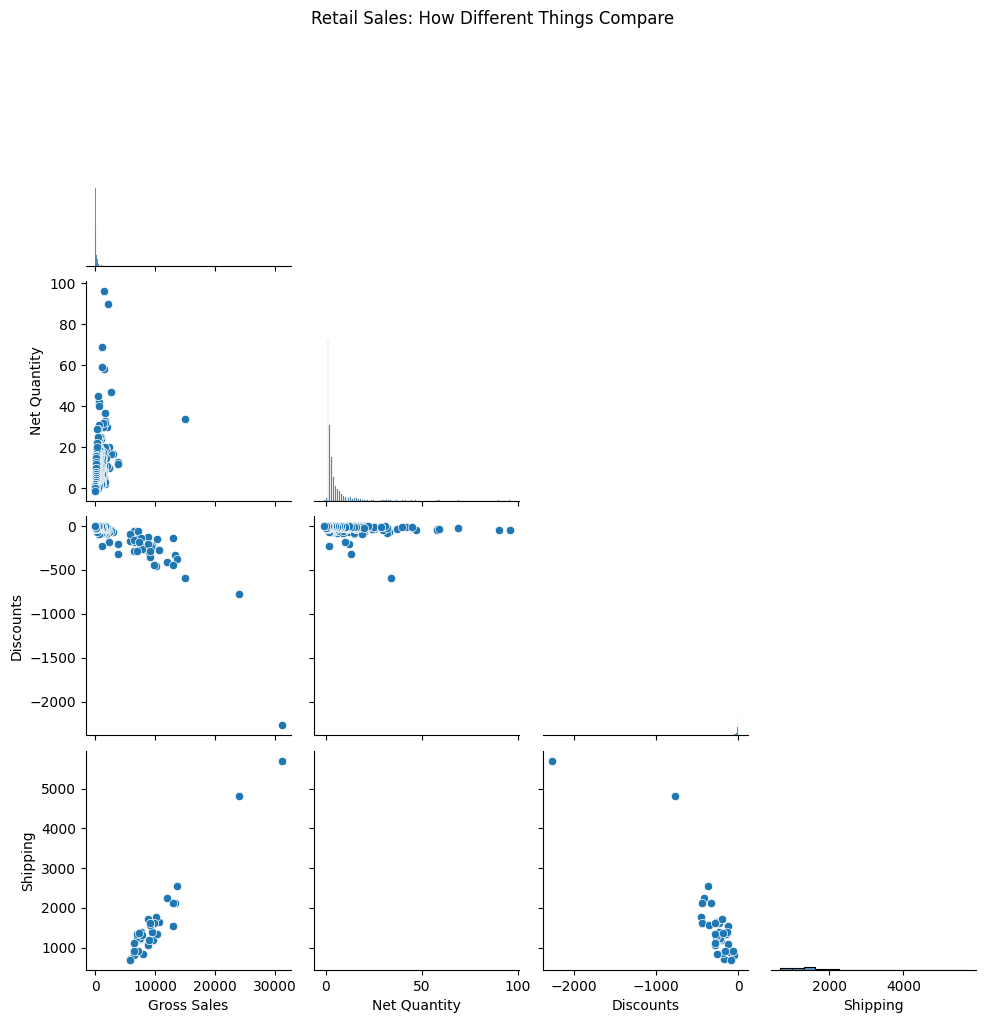

In [14]:
# Let's make sure 'Product Type' doesn't have any missing values before plotting
df_retail['Product Type'] = df_retail['Product Type'].fillna('Unknown')

# Let's pick some numbers we want to compare for our retail sales
vars_to_plot_retail = [
    "Gross Sales",
    "Net Quantity",
    "Discounts",
    "Shipping"
]

# Make the PairPlot!
# `data=df_retail` - using our retail sales info.
# `vars=vars_to_plot_retail` - picked these specific things to compare.
# We are removing `hue="Product Type"` here because it was causing issues with too many categories.
# `palette="tab10"` is another set of nice colors (though won't be used without hue).
# `diag_kind="hist"` - this time, on the diagonal, we draw bar charts to show how many sales fall into different groups.
# `corner=True` - only draw half the pictures.
# `height=2.5` - makes each little picture a good size.
sns.pairplot(
    data=df_retail,
    vars=vars_to_plot_retail,
    diag_kind="hist",
    corner=True,
    height=2.5
)

# Give our big picture a name!
plt.suptitle("Retail Sales: How Different Things Compare", y=1.02)
plt.show()

### B. `FacetGrid` for Retail Data: Sales Stories in Little Books! 📚

Now for our retail sales, we want to see how `Gross Sales` (all the money we got) compares to `Total Net Sales` (how much money we actually kept after discounts and returns). We don't have a 'Region' column, so we'll organize these pictures just by `Product Type` (like toys, books, or candy) in columns. `FacetGrid` is perfect for this! We'll make many little 'books' of pictures. Each book will be for a different `Product Type`. Inside each book, we'll see a picture of `Gross Sales` versus `Total Net Sales`, and we can even draw a little line to show the general trend!

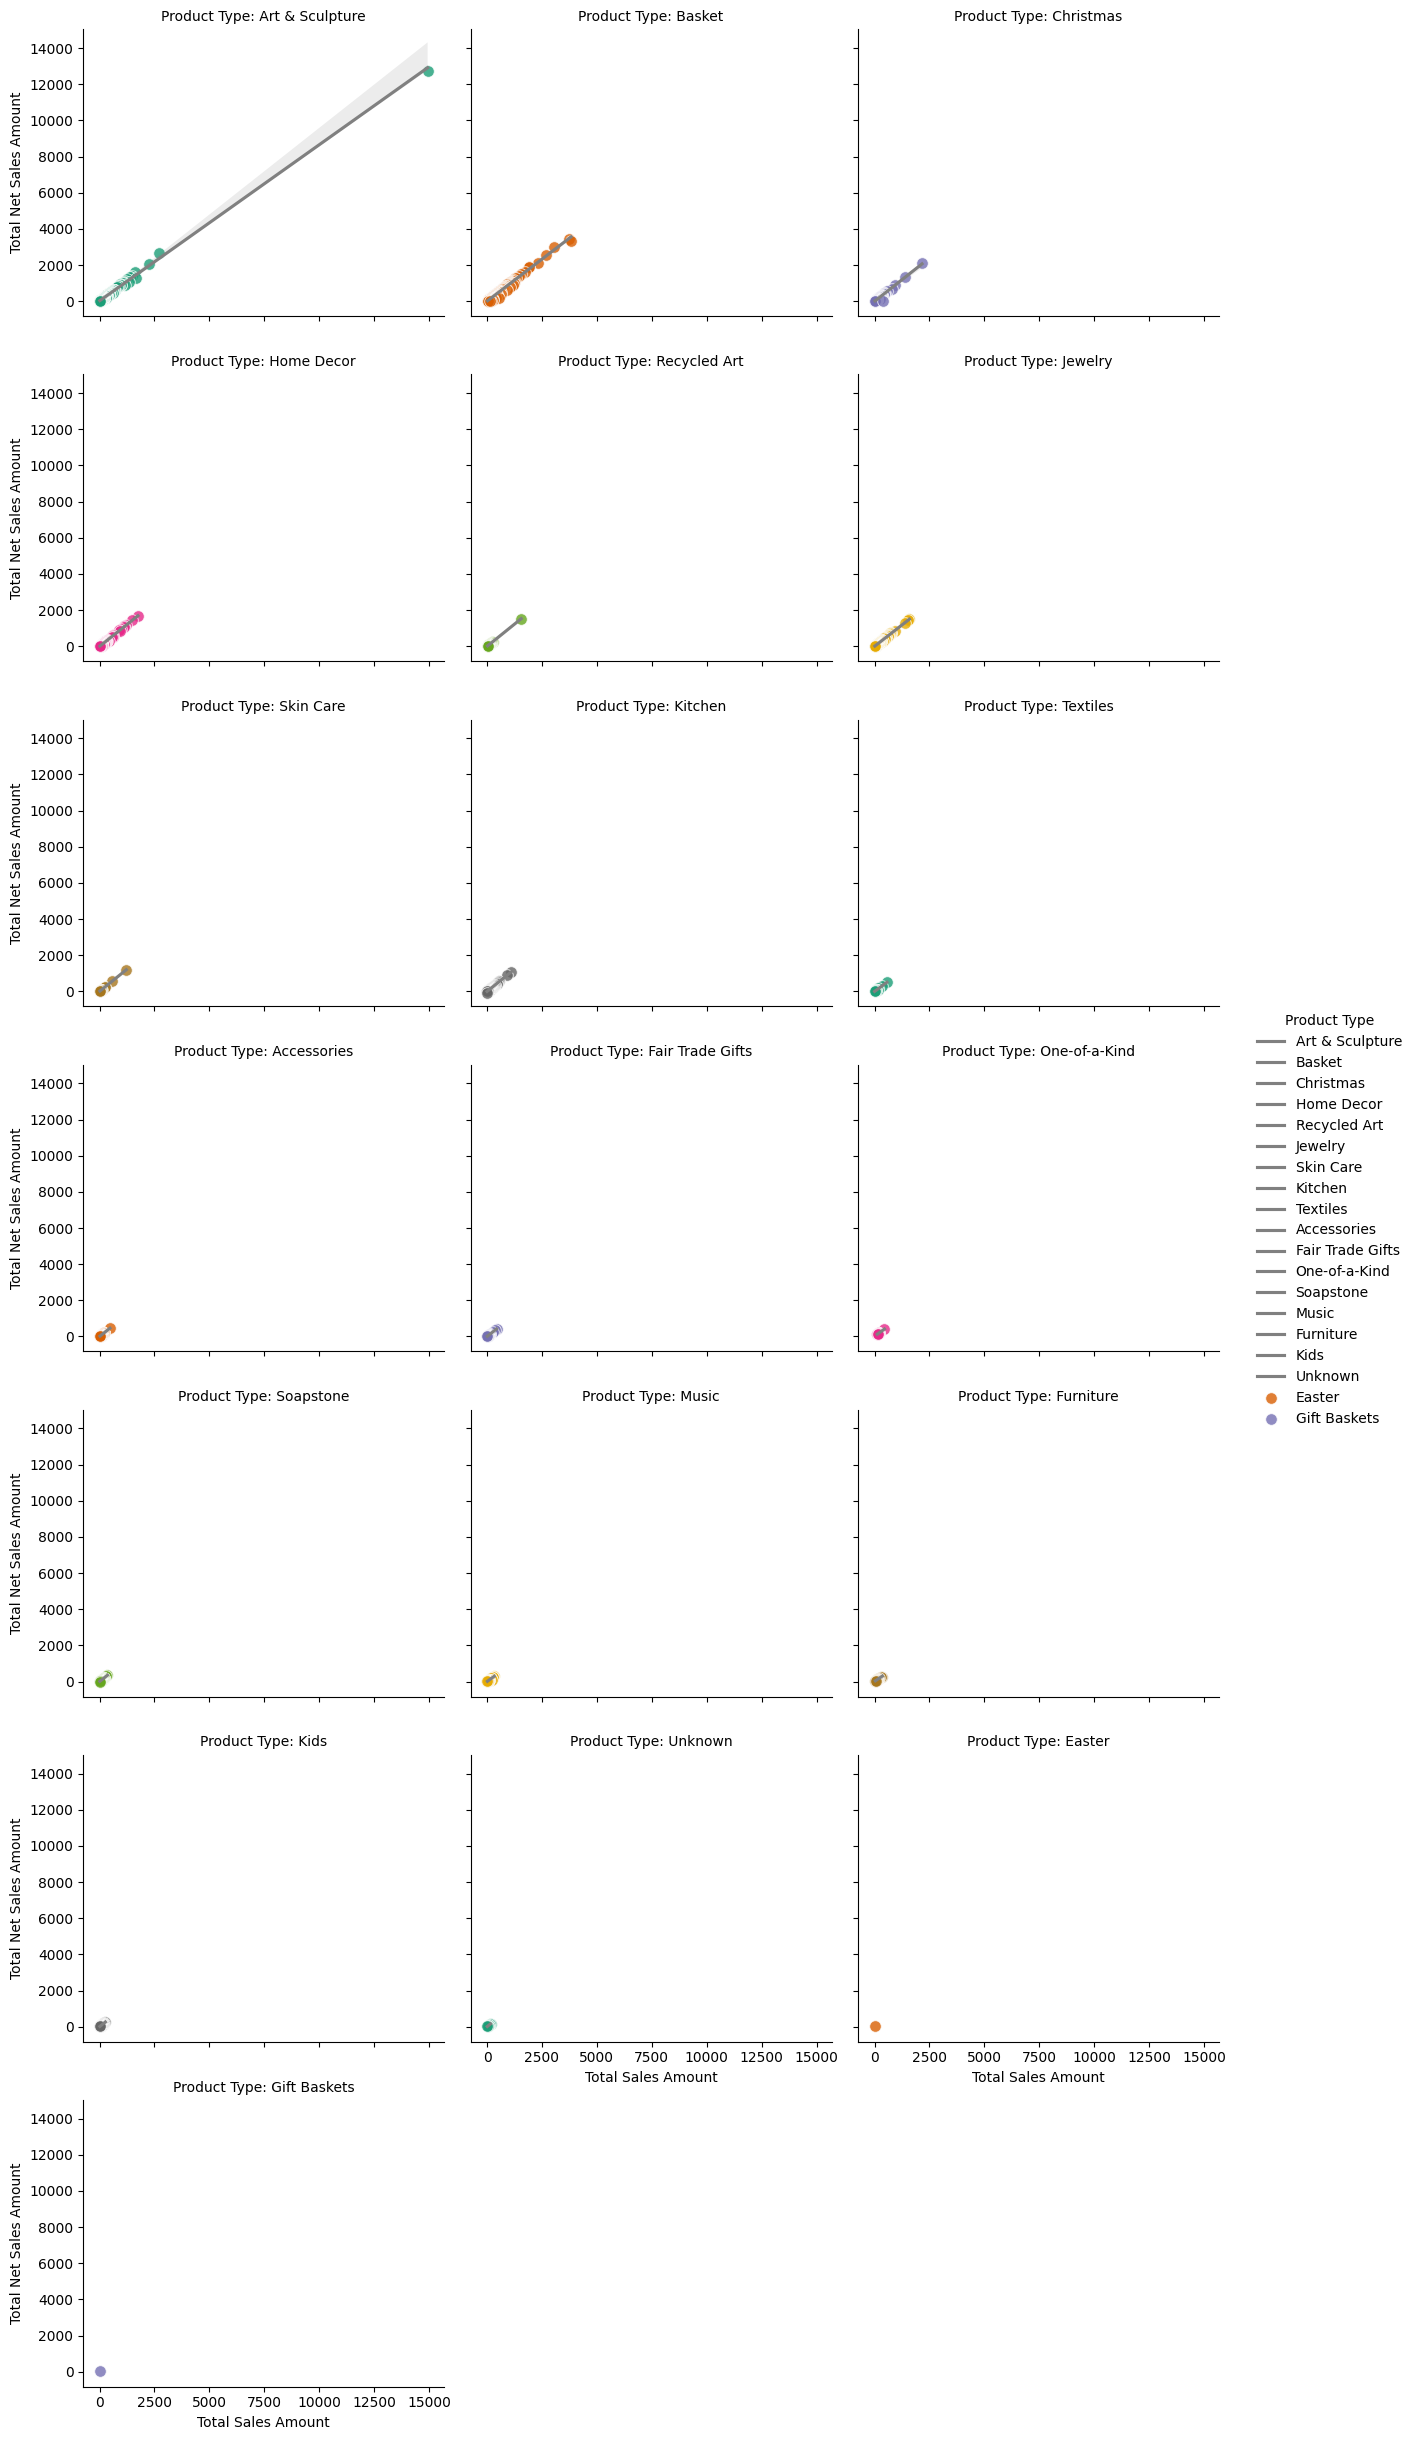

In [15]:
# 1. Get ready to draw our organized sales pictures!
# We already filled missing 'Product Type' values in the previous cell, so it's ready.
# `data=df_retail` - using our retail sales info.
# `col="Product Type"` - sales for different types of items (like 'toys' or 'books') in different columns.
# `hue="Product Type"` - color the dots based on the product type.
# `palette="Dark2"` - more nice colors.
# `height=3.5`, `aspect=1.2` - make the windows a good size.
g_retail = sns.FacetGrid(
    data=df_retail,
    col="Product Type",
    hue="Product Type",
    palette="Dark2",
    height=3.5,
    aspect=1.2,
    col_wrap=3 # Use col_wrap since we only have 'col' for organization
)

# 2. Draw dots in each window! Each dot is one sale.
# `sns.scatterplot` makes little dots.
# `x="Gross Sales"` - how much money we got from this sale (left-to-right).
# `y="Total Net Sales"` - how much money we kept from this sale (bottom-to-top).
# `s=70`, `alpha=0.8` - makes the dots big enough and a bit see-through.
g_retail.map_dataframe(
    sns.scatterplot,
    x="Gross Sales",
    y="Total Net Sales",
    s=70,
    alpha=0.8
)

# 3. Add a soft line to see the trend.
# `sns.regplot` draws a line that shows where the dots usually go.
# `scatter=False` - we already have dots.
# `color="gray"` - makes the line gray.
g_retail.map_dataframe(
    sns.regplot,
    x="Gross Sales",
    y="Total Net Sales",
    scatter=False,
    color="gray"
)

# 4. Give names to our axes and the window titles.
# `set_axis_labels` - names for the bottom and side of each picture.
# `set_titles` - names for the tops of the windows.
g_retail.set_axis_labels("Total Sales Amount", "Total Net Sales Amount")
g_retail.set_titles(col_template="Product Type: {col_name}")
g_retail.add_legend(title="Product Type") # Add a little key to understand the colors
g_retail.tight_layout()
plt.show()